In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf


# Importing Training Data-set
we import the train data-set using `read_csv` method.

-we verify that the imported data

In [18]:
titanic_data = pd.read_csv("train.csv")
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Making the Correlation Heatmap using Seaborn
We use `heatmap` to indicate our data and use the method `corr` on our data and set `numeric_only` to not take strings like names (e.g. Braud. Mr. Qwen Harris)

Also show the plot of course (your ML vision is important in solving problems efficiently).

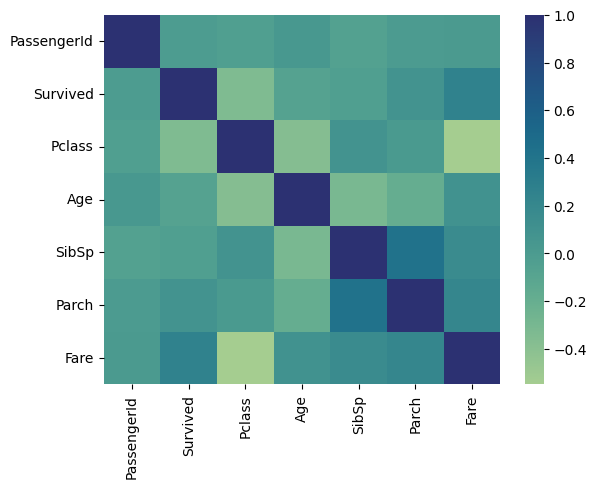

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(titanic_data.corr(numeric_only=True), cmap="crest")
plt.show()

We'll `StratifiedShuffleSplit` to divide our data to training data and testing data.

But why not divide with `pd` isn't is fast? The answer is **Yes**, but there's a hard trade-off testing data need to represent a big set of data so we need to ensure randomness and balance. In other words, we'll shuffle it like a deck of cards.

Another important thing in this part:


```
for train_indices, test_indices in split.split(titanic_data, titanic_data[["Survived", "Pclass", "Sex"]]):
  strat_train_set  = titanic_data.loc[train_indices]
  strat_test_set = titanic_data.loc[test_indices]
```
We shuffled according to `Survived`, `Pclass` and `Sex` because you don't want survived people only to be in your testing data or opposite, and you want to consider the social class of someone, a wealthy man will get help and something similar happen to `Sex`, women had chance to ride safety boats fast because "Women First".

In [20]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_indices, test_indices in split.split(titanic_data, titanic_data[["Survived", "Pclass", "Sex"]]):
  strat_train_set  = titanic_data.loc[train_indices]
  strat_test_set = titanic_data.loc[test_indices]

# Check the Distribution between Training and Testing data
as you can see when plotting the graphs, they're nearly similar that because distribution is balanced between training data and testing data.

--> You can also verify `Sex`.

<Axes: >

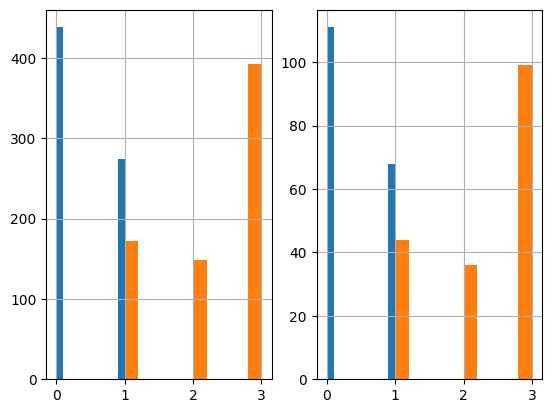

In [21]:
plt.subplot(1,2,1)
strat_train_set['Survived'].hist()
strat_train_set['Pclass'].hist()

plt.subplot(1,2,2)
strat_test_set['Survived'].hist()
strat_test_set['Pclass'].hist()
#

# Detecting Missing Values (null values)
As you can see below Age we've some non-null values below 712 for some modalities (Age, Cabin). There two solutions:

1- Delete it and lose data and get a bad model

2- Getting the best results by using these data even it has missing parts by completing those missings


We'll do the second solution

In [22]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 867 to 802
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    object 
 4   Sex          712 non-null    object 
 5   Age          565 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    object 
 9   Fare         712 non-null    float64
 10  Cabin        167 non-null    object 
 11  Embarked     710 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 72.3+ KB


# Fill Age Missing Fields
We'll fill age empty fields with mean values (`strategy="mean"`)

And about the class `AgeImputer` it is scikit-learn compatible transformer, note `BaseEstimator, TransformerMixin`

In [23]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer

class AgeImputer(BaseEstimator, TransformerMixin):

  def fit(self, X, y=None):
    return self

  def transform(self, X):
    imputer = SimpleImputer(strategy="mean")
    X['Age'] = imputer.fit_transform(X[['Age']])
    return X

In [24]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class FeatureEncoder(BaseEstimator, TransformerMixin):

  def fit(self, X, y=None):
    # Fit Embarked encoder on training data
    X_embarked_temp = X[['Embarked']].fillna('N')
    self.encoder_embarked = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    self.encoder_embarked.fit(X_embarked_temp)

    # Fit Sex encoder on training data, <<this data doesn't have null values>>
    self.encoder_sex = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    self.encoder_sex.fit(X[['Sex']])

    return self

  def transform(self, X):
    X_copy = X.copy()

    # Process 'Embarked' feature using the fitted encoder
    X_embarked_temp = X_copy[['Embarked']].fillna('N') #this is important to not have errors
    matrix_embarked = self.encoder_embarked.transform(X_embarked_temp)
    column_names_embarked = self.encoder_embarked.get_feature_names_out(['Embarked'])
    df_embarked = pd.DataFrame(matrix_embarked, columns=column_names_embarked, index=X_copy.index)
    X_copy = pd.concat([X_copy, df_embarked], axis=1)

    # Process 'Sex' feature using the fitted encoder
    matrix_sex = self.encoder_sex.transform(X_copy[['Sex']])
    column_names_sex = self.encoder_sex.get_feature_names_out(['Sex'])
    df_sex = pd.DataFrame(matrix_sex, columns=column_names_sex, index=X_copy.index)
    X_copy = pd.concat([X_copy, df_sex], axis=1)

    # Drop the original 'Embarked' and 'Sex' columns after encoding
    X_copy = X_copy.drop(columns=['Embarked', 'Sex'], errors='ignore')

    return X_copy

# Features Dropping
Drop features that doesn't really affect the final result. Name is not really connected to your chance of survival. Same goes for ticket price and cabin.

In [25]:

class FeatureDropper(BaseEstimator, TransformerMixin):

  def fit(self, X, y=None):
    return self

  def transform(self, X):
    # Drop the specified columns
    return X.drop(["Name", "Ticket", "Cabin"], axis=1, errors = "ignore")

# Pipeline
This pipeline will run on our data, and will fix the flaws we discussed before

In [26]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
  ("ageimputer", AgeImputer()),
  ("featureencoder", FeatureEncoder()),
  ("featuredropper", FeatureDropper())
])

In [27]:
strat_train_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
867,868,0,1,"Roebling, Mr. Washington Augustus II",male,31.0,0,0,PC 17590,50.4958,A24,S
619,620,0,2,"Gavey, Mr. Lawrence",male,26.0,0,0,31028,10.5000,NaN,S
50,51,0,3,"Panula, Master. Juha Niilo",male,7.0,4,1,3101295,39.6875,NaN,S
286,287,1,3,"de Mulder, Mr. Theodore",male,30.0,0,0,345774,9.5000,NaN,S
834,835,0,3,"Allum, Mr. Owen George",male,18.0,0,0,2223,8.3000,NaN,S


In [28]:
strat_train_set = pipeline.fit_transform(strat_train_set)

In [29]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 867 to 802
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Age          712 non-null    float64
 4   SibSp        712 non-null    int64  
 5   Parch        712 non-null    int64  
 6   Fare         712 non-null    float64
 7   Embarked_C   712 non-null    float64
 8   Embarked_N   712 non-null    float64
 9   Embarked_Q   712 non-null    float64
 10  Embarked_S   712 non-null    float64
 11  Sex_female   712 non-null    float64
 12  Sex_male     712 non-null    float64
dtypes: float64(8), int64(5)
memory usage: 77.9 KB


#Standard Scaler
We'll use standard scaler which adds a small deviation to our

In [30]:
from sklearn.preprocessing import StandardScaler
X = strat_train_set.drop("Survived", axis=1)
y = strat_train_set["Survived"]

scaler = StandardScaler()
X_data = scaler.fit_transform(X) #use our standard scaler
y_data = y.to_numpy() #turn it into numpy array

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

clf = RandomForestClassifier()

param_grid = [
    {'n_estimators': [10,100,200,500], "max_depth": [None, 5, 10], "min_samples_split": [2, 3, 4]}

]
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring="accuracy", return_train_score=True)
grid_search.fit(X_data, y_data)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid=[{'max_depth': [None, 5, 10],
                          'min_samples_split': [2, 3, 4],
                          'n_estimators': [10, 100, 200, 500]}],
             return_train_score=True, scoring='accuracy')

In [32]:
final_clf = grid_search.best_estimator_
final_clf

RandomForestClassifier(max_depth=5, n_estimators=200)

In [33]:
strat_test_set = pipeline.transform(strat_test_set)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [34]:
strat_test_set

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_C,Embarked_N,Embarked_Q,Embarked_S,Sex_female,Sex_male
659,660,0,1,58.00000,0,2,113.2750,1.0,0.0,0.0,0.0,0.0,1.0
119,120,0,3,2.00000,4,2,31.2750,0.0,0.0,0.0,1.0,1.0,0.0
875,876,1,3,15.00000,0,0,7.2250,1.0,0.0,0.0,0.0,1.0,0.0
67,68,0,3,19.00000,0,0,8.1583,0.0,0.0,0.0,1.0,0.0,1.0
644,645,1,3,0.75000,2,1,19.2583,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86,1,3,33.00000,3,0,15.8500,0.0,0.0,0.0,1.0,1.0,0.0
687,688,0,3,19.00000,0,0,10.1708,0.0,0.0,0.0,1.0,0.0,1.0
538,539,0,3,29.44349,0,0,14.5000,0.0,0.0,0.0,1.0,0.0,1.0
279,280,1,3,35.00000,1,1,20.2500,0.0,0.0,0.0,1.0,1.0,0.0


In [35]:
X_test = strat_test_set.drop("Survived", axis=1)
y_test = strat_test_set["Survived"]

scaler = StandardScaler()
X_data_test = scaler.fit_transform(X_test)
y_data_test = y_test.to_numpy()

In [36]:
final_clf.score(X_data_test, y_data_test)

0.8212290502793296

In [37]:
final_data = pipeline.fit_transform(titanic_data)

In [38]:
final_data

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_C,Embarked_N,Embarked_Q,Embarked_S,Sex_female,Sex_male
0,1,0,3,22.000000,1,0,7.2500,0.0,0.0,0.0,1.0,0.0,1.0
1,2,1,1,38.000000,1,0,71.2833,1.0,0.0,0.0,0.0,1.0,0.0
2,3,1,3,26.000000,0,0,7.9250,0.0,0.0,0.0,1.0,1.0,0.0
3,4,1,1,35.000000,1,0,53.1000,0.0,0.0,0.0,1.0,1.0,0.0
4,5,0,3,35.000000,0,0,8.0500,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,13.0000,0.0,0.0,0.0,1.0,0.0,1.0
887,888,1,1,19.000000,0,0,30.0000,0.0,0.0,0.0,1.0,1.0,0.0
888,889,0,3,29.699118,1,2,23.4500,0.0,0.0,0.0,1.0,1.0,0.0
889,890,1,1,26.000000,0,0,30.0000,1.0,0.0,0.0,0.0,0.0,1.0


In [39]:
X_final = final_data.drop(['Survived'], axis=1)
y_final = final_data['Survived']

scaler = StandardScaler()
X_data_final = scaler.fit_transform(X_final)
y_data_final = y_final.to_numpy()

In [40]:
prod_clf = RandomForestClassifier()

param_grid = [
    {'n_estimators': [10,100,200,500], "max_depth": [None, 5, 10], "min_samples_split": [2, 3, 4]}

]
grid_search = GridSearchCV(prod_clf, param_grid, cv=5, scoring="accuracy", return_train_score=True)
grid_search.fit(X_data_final, y_data_final)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid=[{'max_depth': [None, 5, 10],
                          'min_samples_split': [2, 3, 4],
                          'n_estimators': [10, 100, 200, 500]}],
             return_train_score=True, scoring='accuracy')

In [41]:
prod_final_clf = grid_search.best_estimator_
prod_final_clf

RandomForestClassifier(max_depth=10, min_samples_split=4)

In [42]:
titanic_test_data = pd.read_csv("test.csv")

In [43]:
final_test_data = pipeline.transform(titanic_test_data)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [44]:
final_test_data

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Embarked_C,Embarked_N,Embarked_Q,Embarked_S,Sex_female,Sex_male
0,892,3,34.50000,0,0,7.8292,0.0,0.0,1.0,0.0,0.0,1.0
1,893,3,47.00000,1,0,7.0000,0.0,0.0,0.0,1.0,1.0,0.0
2,894,2,62.00000,0,0,9.6875,0.0,0.0,1.0,0.0,0.0,1.0
3,895,3,27.00000,0,0,8.6625,0.0,0.0,0.0,1.0,0.0,1.0
4,896,3,22.00000,1,1,12.2875,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,30.27259,0,0,8.0500,0.0,0.0,0.0,1.0,0.0,1.0
414,1306,1,39.00000,0,0,108.9000,1.0,0.0,0.0,0.0,1.0,0.0
415,1307,3,38.50000,0,0,7.2500,0.0,0.0,0.0,1.0,0.0,1.0
416,1308,3,30.27259,0,0,8.0500,0.0,0.0,0.0,1.0,0.0,1.0


In [45]:
X_final_test = final_test_data
X_final_test = X_final_test.fillna(method = "ffill")

scaler = StandardScaler()
X_data_final_test = scaler.fit_transform(X_final_test)

/tmp/ipykernel_1395/485946229.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_final_test = X_final_test.fillna(method = "ffill")


In [46]:
predictions = prod_final_clf.predict(X_data_final_test)

In [47]:
final_df = pd.DataFrame(titanic_test_data['PassengerId'])
final_df['Survived'] = predictions
final_df.to_csv("predictions.csv", index=False)

In [48]:
final_df

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
